## Navigo KO: Limb Mesenchyme Pathway Enrichment

This tutorial simulates Gli2 knockout in limb mesenchyme cells and compares Navigo-predicted pathway enrichment to ground-truth experimental data.

In [1]:
import warnings
import anndata
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import matplotlib.pyplot as plt
from pathlib import Path

import navigo
from navigo import run_perturbation_inference, set_seed

warnings.filterwarnings('ignore')
%config InlineBackend.figure_format = 'retina'

## Configuration

In [2]:
DATA_DIR       = Path("/scratch/users/steorra/analysis/26_yimin/data")
CHECKPOINT_DIR = Path("/scratch/users/steorra/analysis/26_yimin/checkpoints")
OUTPUT_DIR     = Path("/scratch/users/steorra/analysis/26_yimin/Navigo-release/docs/tutorials/outputs")

data_root       = DATA_DIR / 'knockout'
checkpoints_root = CHECKPOINT_DIR / 'knockout'
case_output_root = OUTPUT_DIR / 'knockout_limb_pathway_enrichment'

CELL_TYPE       = 'Limb#mesenchyme#trajectory'
TARGET_GENE_ID  = 'ENSMUSG00000048402'  # Gli2
KEEP_DAYS       = ['E12.5', 'E12.75', 'E13.0', 'E13.25', 'E13.5']

CHECKPOINT_PATH  = checkpoints_root / 'limb_mesenchyme_knockout_checkpoint_9.pth'
RAW_DATA_PATH    = data_root / 'limb_mesenchyme_trajectory.h5ad'
GT_PATHWAY_TABLE = data_root / 'gene_compensation' / 'gli_output' / 'all_pathway_results.csv'

RUNTIME_DIR  = case_output_root / '00_runtime_inputs'
INFERRED_DIR = case_output_root / '01_inference_csv'
METRIC_DIR   = case_output_root / '02_metrics_tables'
FIGURE_DIR   = case_output_root / '03_figures'

for p in [RUNTIME_DIR, INFERRED_DIR, METRIC_DIR, FIGURE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
set_seed(0)

## Step 1: Prepare subset and run Gli2 knockout

Subset limb mesenchyme cells to the relevant developmental window and run perturbation inference.

In [3]:
adata_raw = anndata.read_h5ad(RAW_DATA_PATH)
adata_subset = adata_raw[adata_raw.obs['day'].isin(KEEP_DAYS)].copy()
adata_subset.obs['cell_type'] = CELL_TYPE

subset_h5ad_path     = RUNTIME_DIR / '01_limb_mesenchyme_subset.h5ad'
target_list_txt_path = RUNTIME_DIR / '01_targets_used.txt'
adata_subset.write_h5ad(subset_h5ad_path)
target_list_txt_path.write_text(TARGET_GENE_ID + '\n')

inference_summary = run_perturbation_inference(
    data_path=subset_h5ad_path, checkpoint_path=CHECKPOINT_PATH,
    target_list_path=target_list_txt_path, output_dir=INFERRED_DIR,
    fibro_cell_type=CELL_TYPE, input_dim=7804, hidden_1=5012, hidden_2=5012,
    flow_num_steps=100, simulation_steps=10, knockout_scale=0.0, device=DEVICE,
    strict_target_presence=True,
)
print(f"Target: {TARGET_GENE_ID} | CSVs generated: {len(list(INFERRED_DIR.glob('*.csv')))}")

Perturbation inference:   0%|                                                                                       | 0/1 [00:00<?, ?it/s]

Perturbation inference: 100%|███████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.69it/s]

Perturbation inference: 100%|███████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.68it/s]

Target: ENSMUSG00000048402 | CSVs generated: 1


## Step 2: Compare predicted and real pathway enrichment

In [4]:
short_name_map = {
    'HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION': 'EMT',
    'REACTOME_SIGNALING_BY_WNT': 'WNT',
    'REACTOME_SIGNALING_BY_HEDGEHOG': 'Hedgehog',
    'HALLMARK_PI3K_AKT_MTOR_SIGNALING': 'PI3K/Akt/mTOR',
    'HALLMARK_G2M_CHECKPOINT': 'G2M Checkpoint',
    'HALLMARK_TGF_BETA_SIGNALING': 'TGF Beta',
    'HALLMARK_NOTCH_SIGNALING': 'Notch',
    'HALLMARK_APOPTOSIS': 'Apoptosis',
    'HALLMARK_INFLAMMATORY_RESPONSE': 'Inflammatory',
}

gt_pathway_df = pd.read_csv(GT_PATHWAY_TABLE)
pathway_df = gt_pathway_df[gt_pathway_df['cell_type'].astype(str) == CELL_TYPE].copy()
pathway_df['pathway_short'] = pathway_df['pathway'].map(short_name_map).fillna(pathway_df['pathway'])
compare_table = pathway_df[['pathway', 'pathway_short', 'p_value_pred', 'neg_log10_p_pred', 'p_value_real', 'neg_log10_p_real']].sort_values('neg_log10_p_pred', ascending=False).reset_index(drop=True)
matrix = compare_table.set_index('pathway_short')[['neg_log10_p_pred', 'neg_log10_p_real']].rename(columns={'neg_log10_p_pred': 'Prediction', 'neg_log10_p_real': 'Ground truth'})
matrix.to_csv(METRIC_DIR / '01_limb_mesenchyme_hypergeometric_matrix.csv')
matrix.round(2)

,Prediction,Ground truth
pathway_short,,
EMT,5.83,1.44
WNT,1.47,3.21
Hedgehog,1.31,2.32
PI3K/Akt/mTOR,1.08,0.41
G2M Checkpoint,0.36,0.36
TGF Beta,-0.00,-0.00
Notch,-0.00,0.84
Apoptosis,-0.00,-0.00
Inflammatory,-0.00,-0.00


## Step 3: Heatmap visualization

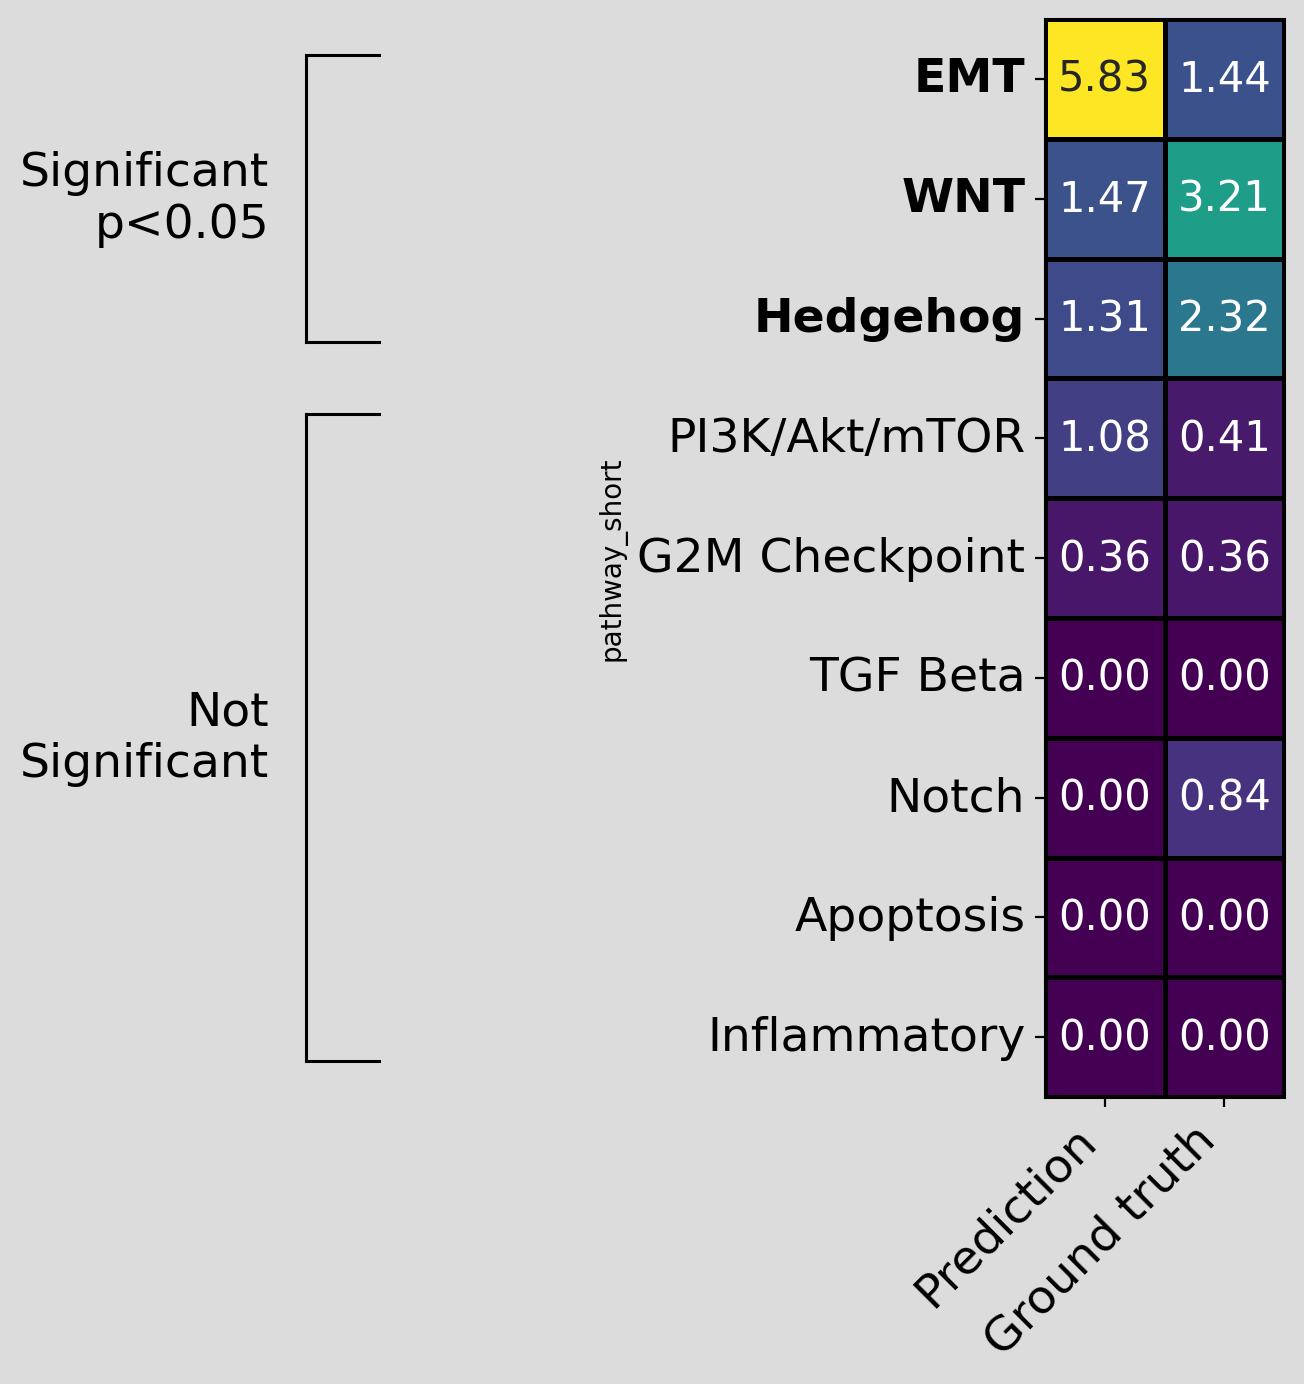

In [5]:
plot_df = matrix.mask(matrix.abs() < 1e-12, 0.0)

fig = plt.figure(figsize=(8.4, 7.0), facecolor='#dcdcdc')
gs = fig.add_gridspec(1, 2, width_ratios=[1.05, 1.15], wspace=0.04)
ax_left = fig.add_subplot(gs[0, 0], facecolor='#dcdcdc')
ax = fig.add_subplot(gs[0, 1], facecolor='#dcdcdc')

sns.heatmap(plot_df, cmap='viridis', annot=True, fmt='.2f', cbar=False, linewidths=1.1, linecolor='black', square=True, annot_kws={'fontsize': 15}, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=17)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=17)
for i, lbl in enumerate(ax.get_yticklabels()):
    if i <= 2:
        lbl.set_fontweight('bold')
for spine in ax.spines.values():
    spine.set_visible(True); spine.set_linewidth(1.1); spine.set_color('black')

ax_left.set_xlim(0, 1); ax_left.set_ylim(ax.get_ylim()); ax_left.axis('off')
ax_left.plot([0.18, 0.30], [0.3, 0.3], color='black', lw=1.1)
ax_left.plot([0.18, 0.30], [2.7, 2.7], color='black', lw=1.1)
ax_left.plot([0.18, 0.18], [0.3, 2.7], color='black', lw=1.1)
ax_left.text(0.12, 1.5, 'Significant\np<0.05', ha='right', va='center', fontsize=17)
ax_left.plot([0.18, 0.30], [3.3, 3.3], color='black', lw=1.1)
ax_left.plot([0.18, 0.30], [8.7, 8.7], color='black', lw=1.1)
ax_left.plot([0.18, 0.18], [3.3, 8.7], color='black', lw=1.1)
ax_left.text(0.12, 6.0, 'Not\nSignificant', ha='right', va='center', fontsize=17)

fig.savefig(FIGURE_DIR / '01_limb_mesenchyme_pathway_heatmap.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()